# Test the Barcelona-trained models on Viladecans

Loads the pickled shallow-learning classifiers and scaler trained on Barcelona (`notebooks/_elena/07_SL_save_model_classification.ipynb`, target **`noise_day`**) and applies them to the Viladecans dataset, comparing predictions with the real noise classes from the strategic noise map.

Outputs go to `../results/`: a predictions CSV and an interactive map of prediction error.

# Data and libraries

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt

In [2]:
# load the Viladecans dataset (same 22-column schema as Barcelona)

data = pd.read_csv("data/vil_noise_class_ml_dataset.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1613 entries, 0 to 1612
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                1613 non-null   str    
 1   noise_day              1613 non-null   int64  
 2   noise_evening          1613 non-null   int64  
 3   noise_night            1613 non-null   int64  
 4   road_category          1613 non-null   int64  
 5   dist_to_trunk          1613 non-null   float64
 6   dist_to_primary        1613 non-null   float64
 7   dist_to_secondary      1613 non-null   float64
 8   dist_to_tertiary       1613 non-null   float64
 9   dist_to_residential    1613 non-null   float64
 10  dist_to_living_street  1613 non-null   float64
 11  signals                1613 non-null   float64
 12  transport              1613 non-null   float64
 13  pois                   1613 non-null   float64
 14  width                  1613 non-null   float64
 15  betweenness    

# Load the Barcelona model artifacts

In [3]:
MODELS_DIR = '../../../notebooks/_elena/models'

with open(f'{MODELS_DIR}/Sscaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open(f'{MODELS_DIR}/feature_columns.pkl', 'rb') as f:
    feature_columns = pickle.load(f)
with open(f'{MODELS_DIR}/logreg_class_model.pkl', 'rb') as f:
    logreg_model = pickle.load(f)
with open(f'{MODELS_DIR}/xgb_class_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)
with open(f'{MODELS_DIR}/rf_class_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

feature_columns

['road_category',
 'dist_to_trunk',
 'dist_to_primary',
 'dist_to_secondary',
 'dist_to_tertiary',
 'dist_to_residential',
 'dist_to_living_street',
 'signals',
 'transport',
 'pois',
 'width',
 'betweenness',
 'closeness_global',
 'closeness_400',
 'straightness',
 'green',
 'industrial',
 'commercial']

In [4]:
# arrange the columns in the exact order the scaler/models were trained on, then scale

X = data[feature_columns]
X_scaled = scaler.transform(X)
y_true = np.asarray(data['noise_day'])

# Predict and compare with the real values

In [5]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

models = {
    'Logistic Regression': logreg_model,
    'XGBoost': xgb_model,
    'Random Forest': rf_model,
}

predictions = {}
rows = []
for name, model in models.items():
    y_pred = model.predict(X_scaled)
    predictions[name] = y_pred
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'within_1_class': np.mean(np.abs(y_pred - y_true) <= 1),
    })

summary = pd.DataFrame(rows).set_index('model').round(4)
summary

,accuracy,macro_f1,within_1_class
model,,,
Logistic Regression,0.5580,0.3847,0.9554
XGBoost,0.5245,0.3047,0.9516
Random Forest,0.4687,0.2899,0.9306


In [6]:
for name in models:
    print(f'==== {name} ====')
    print(classification_report(y_true, predictions[name], zero_division=0))

==== Logistic Regression ====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.56      0.23      0.33       154
           2       0.63      0.58      0.61       686
           3       0.56      0.65      0.60       603
           4       0.35      0.44      0.39       170

    accuracy                           0.56      1613
   macro avg       0.42      0.38      0.38      1613
weighted avg       0.57      0.56      0.55      1613

==== XGBoost ====
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       154
           2       0.51      0.67      0.58       686
           3       0.54      0.64      0.58       603
           4       1.00      0.03      0.06       170

    accuracy                           0.52      1613
   macro avg       0.51      0.33      0.30      1613
weighted avg       0.52      0.52      0.47      1613

==== Random Forest ====
    

### Confusion matrices

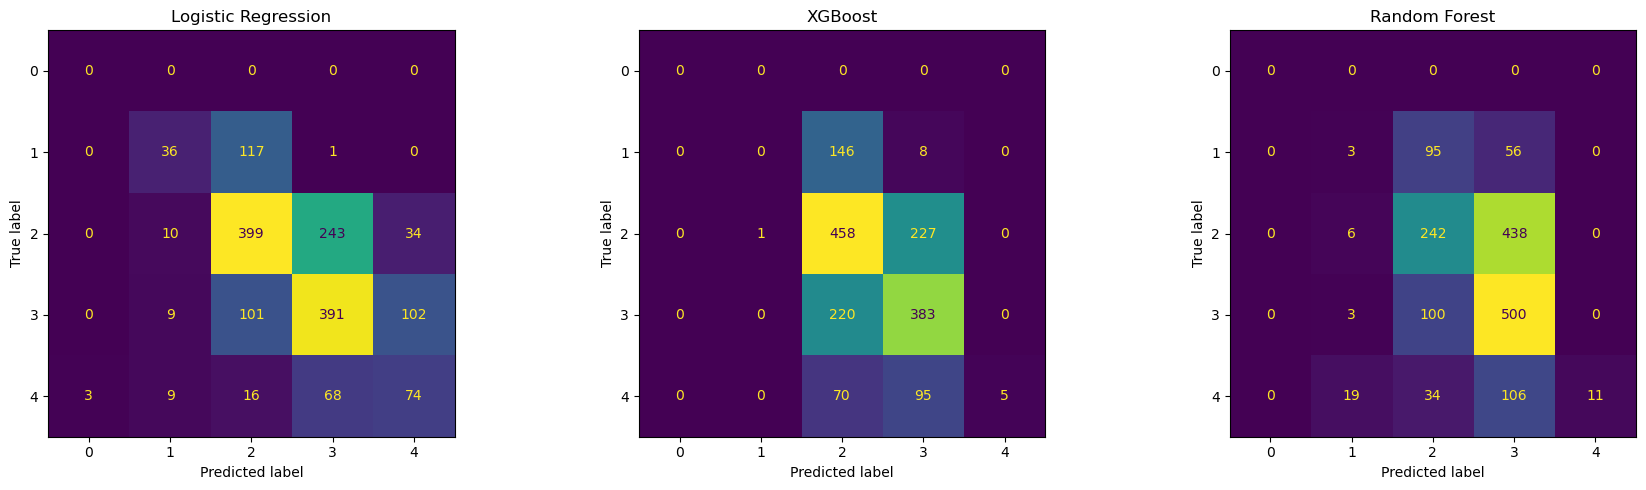

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = [0, 1, 2, 3, 4]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_true, predictions[name], labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap='viridis', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [8]:
# predicted vs real class distribution

dist = pd.DataFrame({'real': pd.Series(y_true).value_counts(normalize=True).sort_index()})
for name in models:
    dist[name] = pd.Series(predictions[name]).value_counts(normalize=True).sort_index()
dist = dist.fillna(0).round(3)
dist.index.name = 'noise_day class'
dist

,real,Logistic Regression,XGBoost,Random Forest
noise_day class,,,,
1,0.095,0.040,0.001,0.019
2,0.425,0.392,0.554,0.292
3,0.374,0.436,0.442,0.682
4,0.105,0.130,0.003,0.007


# Export results

In [9]:
os.makedirs('../results', exist_ok=True)

results = data[['road_id', 'noise_day']].rename(columns={'noise_day': 'noise_day_true'}).copy()
results['pred_logreg'] = predictions['Logistic Regression']
results['pred_xgb'] = predictions['XGBoost']
results['pred_rf'] = predictions['Random Forest']
results['y_diff_rf'] = results['pred_rf'] - results['noise_day_true']

results.to_csv('../results/vil_bcn_model_predictions.csv', index=False)
results.head()

,road_id,noise_day_true,pred_logreg,pred_xgb,pred_rf,y_diff_rf
0,206378333_6315715548_0,3,1,2,2,-1
1,208568922_208568921_0,4,4,4,4,0
2,208568926_208568922_1,4,4,3,4,0
3,208595138_208595144_0,4,4,3,4,0
4,208595144_2332249073_0,4,4,4,4,0


### Visualise prediction error on the map

`y_diff = predicted - real` for the Random Forest (best model on Barcelona): blue = underestimated, red = overestimated, white = correct.

In [10]:
osm_roads = gpd.read_file('../layers/VIL_noise_streets.gpkg')
merged_gdf = osm_roads.merge(results, left_on='segment_id', right_on='road_id', how='left')

m = merged_gdf.to_crs(epsg=4326).explore(
    column='y_diff_rf',
    cmap='RdBu_r',
    vmin=-4, vmax=4,
    tiles='CartoDB positron',
    tooltip=['road_id', 'y_diff_rf', 'pred_rf', 'noise_day_true', 'highway'],
    legend=True,
)
m.save('../results/vil_map_y_diff_rf.html')
m

C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()
